# Online Retail Store

## Secnarij
1. Koje tipove kupaca imamo? - Clustering
2. Hoce li kupac i dalje ostati u trgovini? - Klasifikacija
3. Koliki prihod mozemo ocekivati od kupca u buducem razdoblju? - Regresija


**Dataset**
UCI Online Retails Dataset (https://archive.ics.uci.edu/)

https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

Redoslijed koarak u procesu:
1. ucitavanje podataka
2. razumijevanje podataka
3. ciscenje
4. feature engineering
5. vizualizacije
6. clustering
7. klasifikacija
8. regresija
9. zakljucak

## 1. Uvoz podataka

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (accuracy_score, mean_absolute_error, r2_score)

pd.set_option('display.float_format', '{:,.2f}'.format)

In [4]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[HashableT, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: 

In [9]:
df = pd.read_excel('data/Online Retail.xlsx')
df.head(15)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,"17,850.00",United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,"17,850.00",United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,"17,850.00",United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,"13,047.00",United Kingdom


## 2. Pregled podataka

In [10]:
df.shape

(541909, 8)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [12]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


## 3 Ciscenje podataka

In [14]:
df_clean = df.copy()

In [15]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [16]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [21]:
# Filtriramo sve racune koji pocinju s C jer je to oznaka za Canceled
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

In [22]:
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [23]:
df_clean.duplicated().sum()

np.int64(5192)

In [24]:
df_clean = df_clean.drop_duplicates()

In [25]:
df_clean.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [26]:
df_clean[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,"392,692.00","392,692.00"
mean,13.12,3.13
std,180.49,22.24
min,1.00,0.00
25%,2.00,1.25
50%,6.00,1.95
75%,12.00,3.75
max,"80,995.00","8,142.75"


## 4. Feature engineering

Kreiramo novi stupac ukupna cijena stavke na osnovu podataka iz kolicine i jedinicne vrijednosti

In [28]:
df_clean['LineTotal'] = df_clean.Quantity * df_clean.UnitPrice
# df_clean['LineTotal'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean[['Quantity', 'UnitPrice', 'LineTotal']].head(15)

,Quantity,UnitPrice,LineTotal
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


### Osnovna poslovna analiza

- ukupni prihod
- koje zemlje dominiraju
- kako se prihod mijenja kroz vrijeme
- koji proizvodi se najvise prodaju

In [31]:
total_revenue = df_clean['LineTotal'].sum()
print(f'Ukupan prihod: {total_revenue:,.3f}')

number_of_customers = df_clean['CustomerID'].nunique()
print(f'Broj kupaca: {number_of_customers:,.3f}')

number_of_invoices = df_clean['InvoiceNo'].nunique()
print(f'Broj izdanih racuna: {number_of_invoices:,.3f}')

Ukupan prihod: 8,887,208.894
Broj kupaca: 4,338.000
Broj izdanih racuna: 18,532.000


In [32]:
top_ten_countries = (
    df_clean
    .groupby('Country')['LineTotal']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_ten_countries

Country
United Kingdom   7,285,024.64
Netherlands        285,446.34
EIRE               265,262.46
Germany            228,678.40
France             208,934.31
Australia          138,453.81
Spain               61,558.56
Switzerland         56,443.95
Belgium             41,196.34
Sweden              38,367.83
Name: LineTotal, dtype: float64

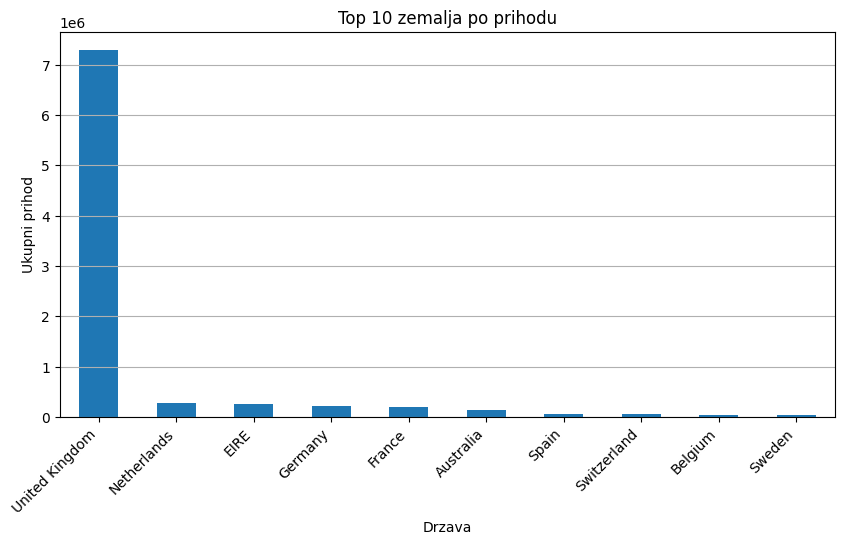

In [35]:
top_ten_countries.plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 zemalja po prihodu'
)

plt.xlabel('Drzava')
plt.ylabel('Ukupni prihod')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

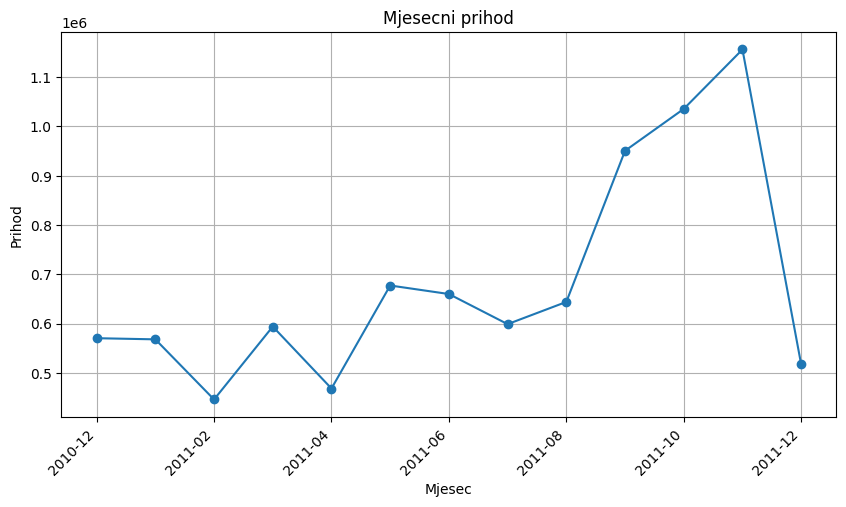

In [39]:
# Dodali smo novi stupac u kojem cemo imati podatke na mjesecnoj razini
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

monthly_revenue = df_clean.groupby('InvoiceMonth')['LineTotal'].sum()

monthly_revenue.plot(
    kind='line',
    marker='o',
    figsize=(10, 5),
    title='Mjesecni prihod'
)

plt.xlabel('Mjesec')
plt.ylabel('Prihod')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

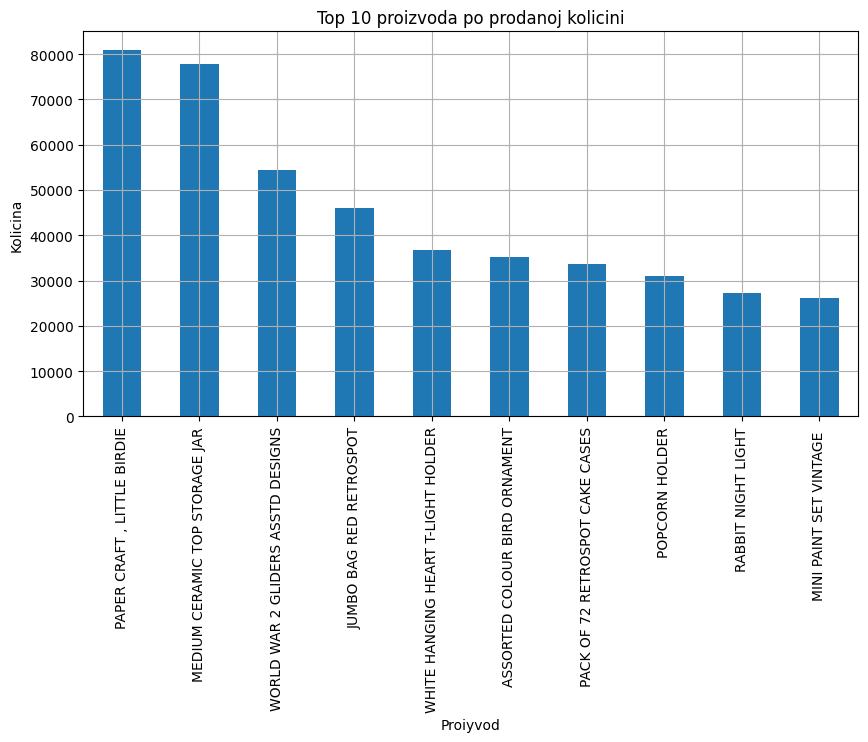

In [42]:
top_ten_products = (
    df_clean
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_ten_products.plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 proizvoda po prodanoj kolicini'
)

plt.xlabel('Proiyvod')
plt.ylabel('Kolicina')
plt.grid(True)
plt.show()

### Transformacija dataseta u Customer first dataset

Prebacivanje dataseta iz transakcijskog (Invoice first) u Customer first dataset

In [47]:
analysis_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

df_customer = (
    df_clean
    .groupby('CustomerID')
    .agg(
        last_purchase_date=('InvoiceDate', 'max'),
        first_purchase_date=('InvoiceDate', 'min'),
        frequency=('InvoiceNo', 'nunique'),
        monetary=('LineTotal', 'sum'),
        total_quantity=('Quantity', 'sum'),
        unique_products=('StockCode', 'nunique'),
        avg_unit_price=('UnitPrice', 'mean'),
        country=('Country', lambda x: x.mode()[0])
    )
    .reset_index()
)

df_customer['recency'] = (analysis_date - df_customer['last_purchase_date']).dt.days
df_customer['customer_lifetime_days'] = (df_customer['last_purchase_date'] - df_customer['first_purchase_date']).dt.days + 1
df_customer['svg_basket_value'] = (df_customer['monetary'] / df_customer['frequency'])

df_customer.head()

,CustomerID,last_purchase_date,first_purchase_date,frequency,monetary,total_quantity,unique_products,avg_unit_price,country,recency,customer_lifetime_days,svg_basket_value
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,"77,183.60",74215,1,1.04,United Kingdom,326,1,"77,183.60"
1,12347,2011-12-07 15:52:00,2010-12-07 14:57:00,7,"4,310.00",2458,103,2.64,Iceland,2,366,615.71
2,12348,2011-09-25 13:13:00,2010-12-16 19:09:00,4,"1,797.24",2341,22,5.76,Finland,75,283,449.31
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,"1,757.55",631,73,8.29,Italy,19,1,"1,757.55"
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,17,3.84,Norway,310,1,334.40


In [48]:
df_customer.shape

(4338, 12)

In [49]:
df_customer.describe()

,CustomerID,last_purchase_date,first_purchase_date,frequency,monetary,total_quantity,unique_products,avg_unit_price,recency,customer_lifetime_days,svg_basket_value
count,"4,338.00",4338,4338,"4,338.00","4,338.00","4,338.00","4,338.00","4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",2011-09-08 11:38:59.045643,2011-04-30 17:06:50.857538,4.27,"2,048.69","1,187.64",61.50,4.47,92.54,131.45,417.65
min,"12,346.00",2010-12-01 09:53:00,2010-12-01 08:26:00,1.00,3.75,1.00,1.00,0.12,1.00,1.00,3.45
25%,"13,813.25",2011-07-20 19:18:00,2011-01-17 11:13:15,1.00,306.48,159.00,16.00,2.21,18.00,1.00,177.87
50%,"15,299.50",2011-10-20 10:40:30,2011-04-05 09:52:30,2.00,668.57,378.00,35.00,2.92,51.00,93.50,291.94
75%,"16,778.75",2011-11-22 11:05:45,2011-08-19 10:11:30,5.00,"1,660.60",989.75,77.00,3.83,142.00,252.75,428.28
max,"18,287.00",2011-12-09 12:50:00,2011-12-09 12:16:00,209.00,"280,206.02","196,915.00","1,787.00","2,033.10",374.00,374.00,"84,236.25"
std,"1,721.81",NaN,NaN,7.70,"8,985.23","5,043.62",85.37,34.22,100.01,132.04,"1,796.51"


### Vizualizacija podataka kupca

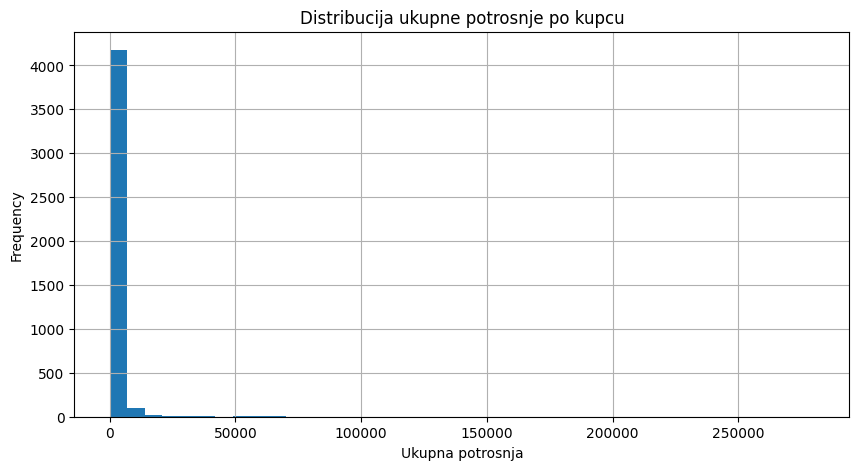

In [50]:
df_customer['monetary'].plot(
    kind='hist',
    bins=40,
    figsize=(10, 5),
    title='Distribucija ukupne potrosnje po kupcu'
)

plt.xlabel('Ukupna potrosnja')
plt.grid(True)

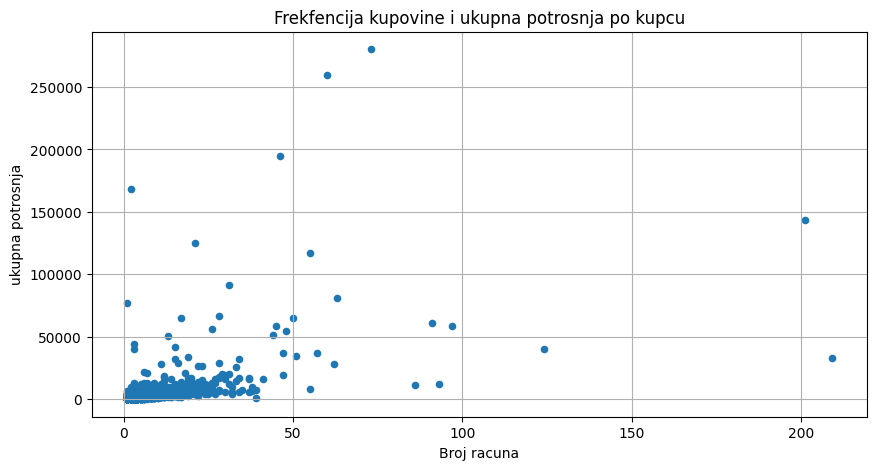

In [52]:
df_customer.plot(
    kind='scatter',
    x='frequency',
    y='monetary',
    figsize=(10, 5),
    title='Frekfencija kupovine i ukupna potrosnja po kupcu'
)

plt.xlabel('Broj racuna')
plt.ylabel('ukupna potrosnja')
plt.grid(True)

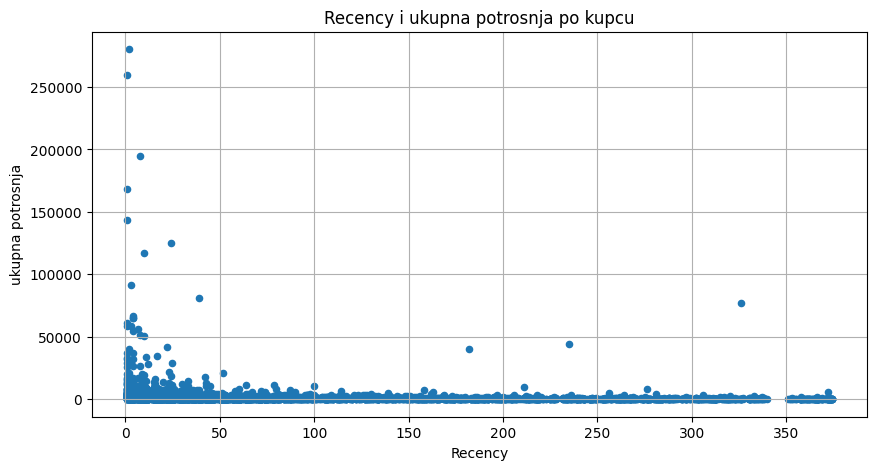

In [53]:
df_customer.plot(
    kind='scatter',
    x='recency',
    y='monetary',
    figsize=(10, 5),
    title='Recency i ukupna potrosnja po kupcu'
)

plt.xlabel('Recency')
plt.ylabel('ukupna potrosnja')
plt.grid(True)

## Clustering

Koje tipove kupaca imamo na osnovu kupovine

- nedavno aktivni - vrijedni
- cesti kupci male vrijednosti
- rijetki kupci ali velike vriednosti
- neaktivni kupci

In [54]:
df_customer.columns

Index(['CustomerID', 'last_purchase_date', 'first_purchase_date', 'frequency',
       'monetary', 'total_quantity', 'unique_products', 'avg_unit_price',
       'country', 'recency', 'customer_lifetime_days', 'svg_basket_value'],
      dtype='str')

In [55]:
cluster_features = [
    'recency',
    'frequency',
    'monetary',
    'total_quantity',
    'unique_products',
    'svg_basket_value',
    'customer_lifetime_days'
]

X_cluster = df_customer[cluster_features].copy()
scalar = StandardScaler()

X_cluster_scalar = scalar.fit_transform(X_cluster)

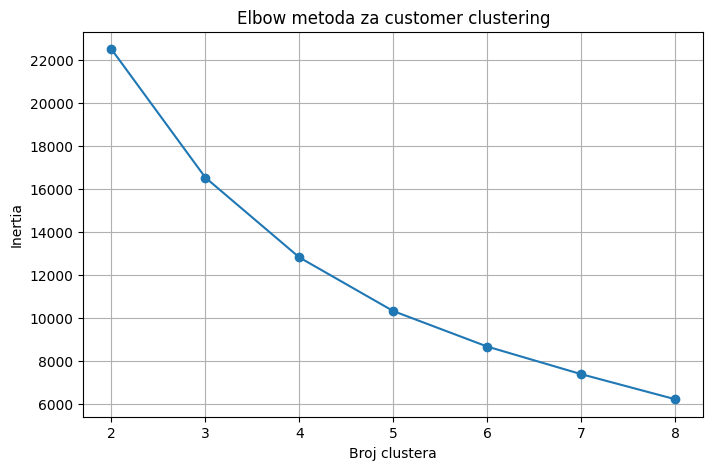

In [56]:
inertias = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_cluster_scalar)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow metoda za customer clustering")
plt.xlabel("Broj clustera")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [57]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_customer['clusters'] = kmeans.fit_predict(X_cluster_scalar)

df_customer[['CustomerID', 'clusters']].head()

,CustomerID,clusters
0,12346,3
1,12347,1
2,12348,1
3,12349,0
4,12350,0


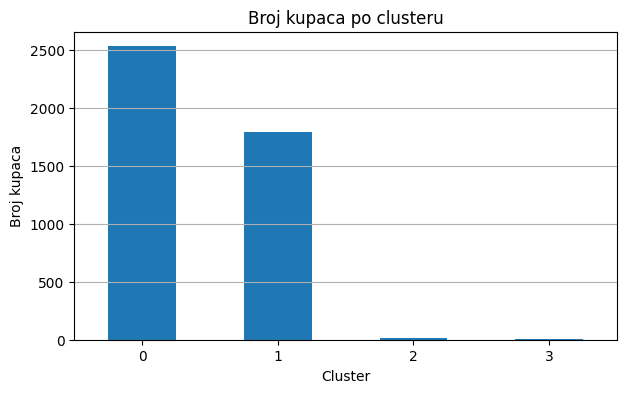

In [59]:
df_customer["clusters"].value_counts().sort_index().plot(kind="bar", figsize=(7, 4), title="Broj kupaca po clusteru")
plt.xlabel("Cluster")
plt.ylabel("Broj kupaca")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [60]:
customer_profile = df_customer.groupby('clusters')[cluster_features].mean()
customer_profile

,recency,frequency,monetary,total_quantity,unique_products,svg_basket_value,customer_lifetime_days
clusters,,,,,,,
0,136.93,1.69,593.54,341.79,28.86,354.66,33.67
1,30.66,7.28,"3,016.35","1,771.60",101.88,400.58,267.40
2,7.19,75.62,"108,334.76","59,787.88",699.88,"2,240.61",343.62
3,163.50,1.50,"122,828.05","77,606.00",2.00,"80,709.93",103.00


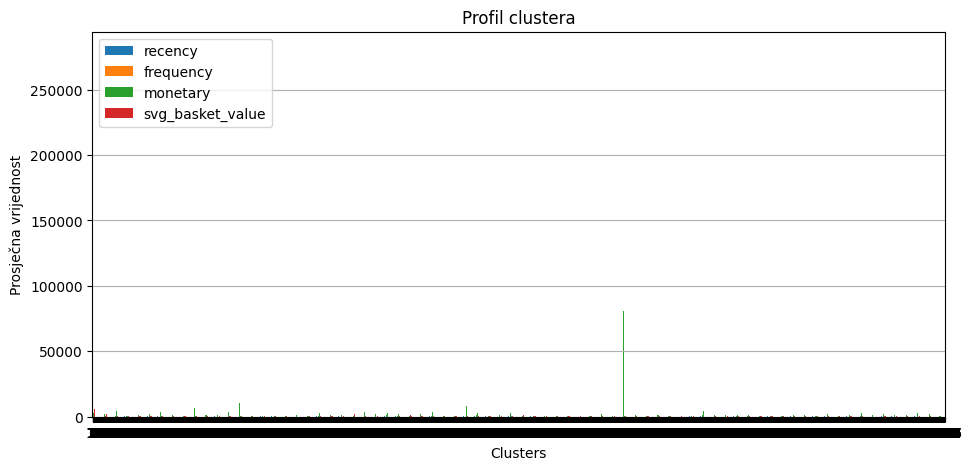

In [64]:
df_customer[["recency", "frequency", "monetary", "svg_basket_value"]].plot(
    kind="bar",
    figsize=(11, 5),
    title="Profil clustera"
)
plt.xlabel("Clusters")
plt.ylabel("Prosječna vrijednost")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()